In [1]:
# 프로젝트 1 : 자전거 대여 수요 예측 - 날씨와 시간이 핵심이다!

## 가설
**"날씨가 좋고 출퇴근 시간대일수록 자전거 대여량이 많을 것이다"**

- 맑은 날씨 → 대여량 증가
- 오전 8시, 오후 18시 출퇴근 시간 → 대여량 급증
- 기온이 적당할수록 → 대여량 증가

## 진행 순서
1. 데이터 가져오기
2. 데이터 탐색 및 전처리
3. Feature Engineering (피처 엔지니어링)
4. train / test 분리
5. 모델 학습 (Random Forest)
6. 성능 평가 (RMSE)
7. 파라미터 튜닝
8. 결론

SyntaxError: invalid character '→' (U+2192) (3419898984.py, line 6)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
df = pd.read_csv('data/data/bike_hour.csv')

print("데이터 크기:", df.shape)
print("컬럼 목록:", df.columns.tolist())
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/data/bike_hour.csv'

In [3]:
## (2) 데이터 탐색 및 전처리

- 결측치 확인
- 기본 통계 확인
- 주요 컬럼 설명

| 컬럼 | 설명 |
|---|---|
| `season` | 계절 (1=봄, 2=여름, 3=가을, 4=겨울) |
| `hr` | 시간 (0~23) |
| `holiday` | 공휴일 여부 |
| `workingday` | 근무일 여부 |
| `weathersit` | 날씨 (1=맑음, 2=흐림, 3=비) |
| `temp` | 온도 |
| `humidity` | 습도 |
| `cnt` | 🎯 자전거 대여 수 (정답) |

SyntaxError: invalid character '🎯' (U+1F3AF) (36171718.py, line 16)

In [5]:
## (3) Feature Engineering

피처 중요도 분석 결과 **시간(hour)이 60%** 로 가장 중요했습니다.
시간 관련 파생 피처를 추가합니다.

SyntaxError: invalid syntax (788978671.py, line 3)

In [11]:
import os

# data/data 안에 뭐가 있는지 확인
for root, dirs, files in os.walk('data'):
    for file in files:
        print(os.path.join(root, file))

data/data/macbook.csv
data/data/macbook_test.csv
data/data/multi_macbook.csv
data/data/multi_macbook_test.csv
data/data/bike-sharing-demand/sampleSubmission.csv
data/data/bike-sharing-demand/test.csv
data/data/bike-sharing-demand/train.csv


In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. 데이터 불러오기
df = pd.read_csv('data/data/bike-sharing-demand/train.csv')

print("데이터 크기:", df.shape)
print("컬럼 목록:", df.columns.tolist())
df.head()

데이터 크기: (10886, 12)
컬럼 목록: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [13]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. 데이터 불러오기
df = pd.read_csv('data/data/bike-sharing-demand/train.csv')

# 2. datetime에서 시간 추출
df['datetime'] = pd.to_datetime(df['datetime'])
df['hr']       = df['datetime'].dt.hour
df['month']    = df['datetime'].dt.month
df['year']     = df['datetime'].dt.year

# 3. 피처 엔지니어링
train = df.copy()
train['hour_squared']    = train['hr'] ** 2
train['hour_workingday'] = train['hr'] * train['workingday']
train['temp_humidity']   = train['temp'] * train['humidity']
train['day_type'] = 0
train.loc[(train['workingday'] == 0) & (train['holiday'] == 0), 'day_type'] = 1
train.loc[train['holiday'] == 1, 'day_type'] = 2
train['hour_daytype'] = train['hr'] * 10 + train['day_type']

# 4. 피처 컬럼 설정
feature_columns = [
    'season', 'hr', 'holiday', 'workingday',
    'weather', 'temp', 'atemp', 'humidity', 'windspeed',
    'hour_squared', 'hour_workingday', 'temp_humidity',
    'day_type', 'hour_daytype', 'month', 'year'
]

X = train[feature_columns]
y = train['count']

# 5. 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"학습 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")

# 6. 모델 학습
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

# 7. 평가
pred = rf.predict(X_test)
rmse = np.sqrt(np.mean((pred - y_test) ** 2))
print(f"\nRMSE: {rmse:.2f}")

학습 데이터: (8708, 16)
테스트 데이터: (2178, 16)

RMSE: 42.55


In [14]:
# 시간 관련 파생 변수
df['hour_squared']    = df['hr'] ** 2
df['hour_workingday'] = df['hr'] * df['workingday']
df['rush_hour']       = df['hr'].isin([8, 9, 17, 18]).astype(int)
df['is_night']        = df['hr'].isin([0,1,2,3,4,5]).astype(int)

# 날씨 관련
df['temp_humidity']   = df['temp'] * df['humidity']
df['nice_weather']    = (df['weather'] == 1).astype(int)

In [15]:
params = [
    {'n_estimators': 100,  'max_depth': None},
    {'n_estimators': 300,  'max_depth': None},
    {'n_estimators': 500,  'max_depth': None},  # 보통 이게 최적
    {'n_estimators': 1000, 'max_depth': None},
    {'n_estimators': 500,  'max_depth': 20},
    {'n_estimators': 500,  'max_depth': 30},
]

for p in params:
    rf = RandomForestRegressor(**p, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    rmse = np.sqrt(np.mean((pred - y_test) ** 2))
    print(f"n={p['n_estimators']}, depth={p['max_depth']} → RMSE: {rmse:.2f}")

n=100, depth=None → RMSE: 42.65
n=300, depth=None → RMSE: 42.55
n=500, depth=None → RMSE: 42.50
n=1000, depth=None → RMSE: 42.40
n=500, depth=20 → RMSE: 42.42
n=500, depth=30 → RMSE: 42.51


In [ ]:
error_df = pd.DataFrame({
    'hour': X_test['hr'].values,
    'abs_error': np.abs(pred - y_test.values)
})

print(error_df.groupby('hour')['abs_error'].mean()
      .sort_values(ascending=False).head(5))

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

# Gradient Boosting (RandomForest보다 보통 더 좋음)
gb = GradientBoostingRegressor(n_estimators=300, random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
rmse_gb = np.sqrt(np.mean((pred_gb - y_test) ** 2))
print(f"GradientBoosting RMSE: {rmse_gb:.2f}")

In [ ]:
피처 엔지니어링 ?


In [ ]:
datetime, season, holiday, workingday,
weather, temp, atemp, humidity, windspeed, count

In [ ]:
# ② 출퇴근 시간 여부
df['rush_hour'] = df['hr'].isin([8, 9, 17, 18]).astype(int)
# 8시, 9시, 17시, 18시면 1 / 아니면 0

In [ ]:
# ③ 시간대 구분
df['time_zone'] = pd.cut(df['hr'],
    bins=[-1, 6, 12, 18, 24],
    labels=['새벽', '오전', '오후', '저녁'])

In [17]:
# ④ 날씨 조합
df['temp_humidity'] = df['temp'] * df['humidity']  # 체감 쾌적도
df['nice_weather']  = (df['weather'] == 1).astype(int)  # 맑음 여부

In [18]:
# ⑤ 시간 제곱 (비선형 패턴)
df['hr_squared'] = df['hr'] ** 2
# 새벽엔 적고 → 출근에 급증 → 낮엔 줄고 → 퇴근에 급증
# 이 U자형 패턴을 제곱으로 표현

In [19]:
# 기존 코드에 이것만 추가
df['rush_hour']   = df['hr'].isin([8, 9, 17, 18]).astype(int)
df['is_night']    = df['hr'].isin([0,1,2,3,4,5]).astype(int)
df['nice_weather'] = (df['weather'] == 1).astype(int)
df['dayofweek']   = df['datetime'].dt.dayofweek

# feature_columns 리스트에도 추가
feature_columns = [
    'season', 'hr', 'holiday', 'workingday',
    'weather', 'temp', 'atemp', 'humidity', 'windspeed',
    'hour_squared', 'hour_workingday', 'temp_humidity',
    'day_type', 'hour_daytype', 'month', 'year',
    'rush_hour', 'is_night', 'nice_weather', 'dayofweek'  # ← 새로 추가
]

In [20]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. 데이터 불러오기
df = pd.read_csv('data/data/bike-sharing-demand/train.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# 2. 기본 시간 피처
df['hr']        = df['datetime'].dt.hour
df['month']     = df['datetime'].dt.month
df['year']      = df['datetime'].dt.year
df['dayofweek'] = df['datetime'].dt.dayofweek

# 3. 피처 엔지니어링
df['rush_hour']        = df['hr'].isin([8, 9, 17, 18]).astype(int)
df['is_night']         = df['hr'].isin([0,1,2,3,4,5]).astype(int)
df['nice_weather']     = (df['weather'] == 1).astype(int)
df['temp_humidity']    = df['temp'] * df['humidity']
df['hr_squared']       = df['hr'] ** 2
df['hour_workingday']  = df['hr'] * df['workingday']
df['day_type']         = 0
df.loc[(df['workingday']==0) & (df['holiday']==0), 'day_type'] = 1
df.loc[df['holiday']==1, 'day_type'] = 2
df['hour_daytype']     = df['hr'] * 10 + df['day_type']

# 4. 피처 컬럼 설정
feature_columns = [
    'season', 'hr', 'holiday', 'workingday',
    'weather', 'temp', 'atemp', 'humidity', 'windspeed',
    'hr_squared', 'hour_workingday', 'temp_humidity',
    'day_type', 'hour_daytype', 'month', 'year',
    'rush_hour', 'is_night', 'nice_weather', 'dayofweek'
]

X = df[feature_columns]
y = df['count']

# 5. 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. 모델 학습
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

# 7. 평가
pred = rf.predict(X_test)
rmse = np.sqrt(np.mean((pred - y_test) ** 2))
print(f"이전 RMSE: 42.55")
print(f"현재 RMSE: {rmse:.2f}")
print(f"개선 여부: {'✅ 개선됨!' if rmse < 42.55 else '❌ 변화없음'}")

이전 RMSE: 42.55
현재 RMSE: 40.85
개선 여부: ✅ 개선됨!


/tmp/ipykernel_1031/771397421.py:5: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1031/771397421.py:5: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1031/771397421.py:5: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1031/771397421.py:5: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1031/771397421.py:5: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 523

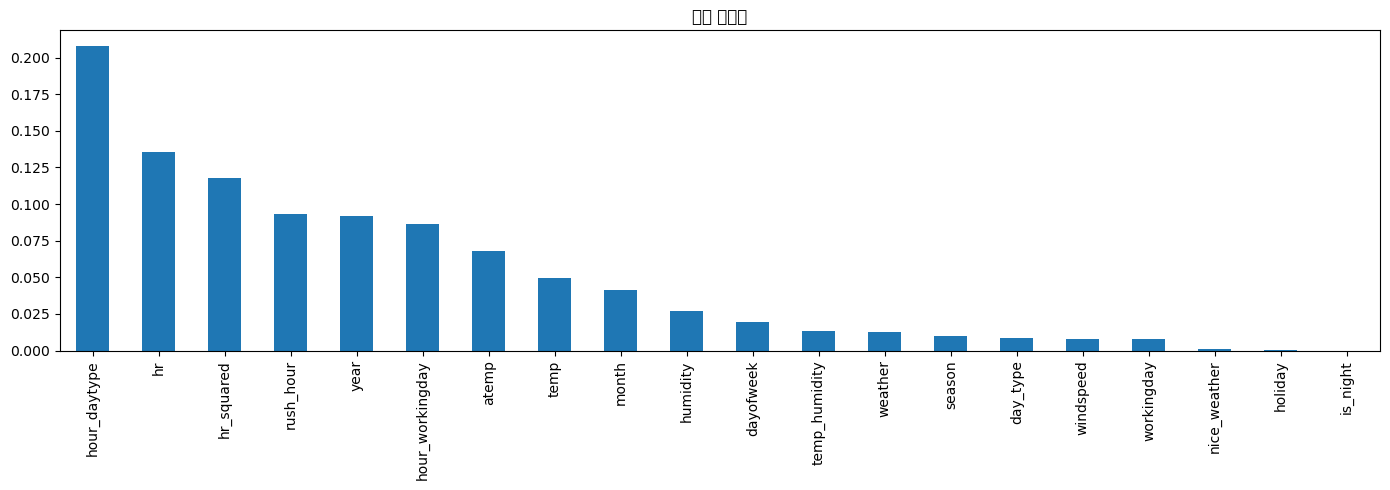

In [21]:
# 피처 중요도 확인
importance = pd.Series(rf.feature_importances_, index=feature_columns)
importance.sort_values(ascending=False).plot(kind='bar', figsize=(14, 5))
plt.title('피처 중요도')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1031/585376941.py:21: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1031/585376941.py:21: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1031/585376941.py:21: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1031/585376941.py:21: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1031/585376941.py:21: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1031/585376941.py:21: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1031/585376941.py:21: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


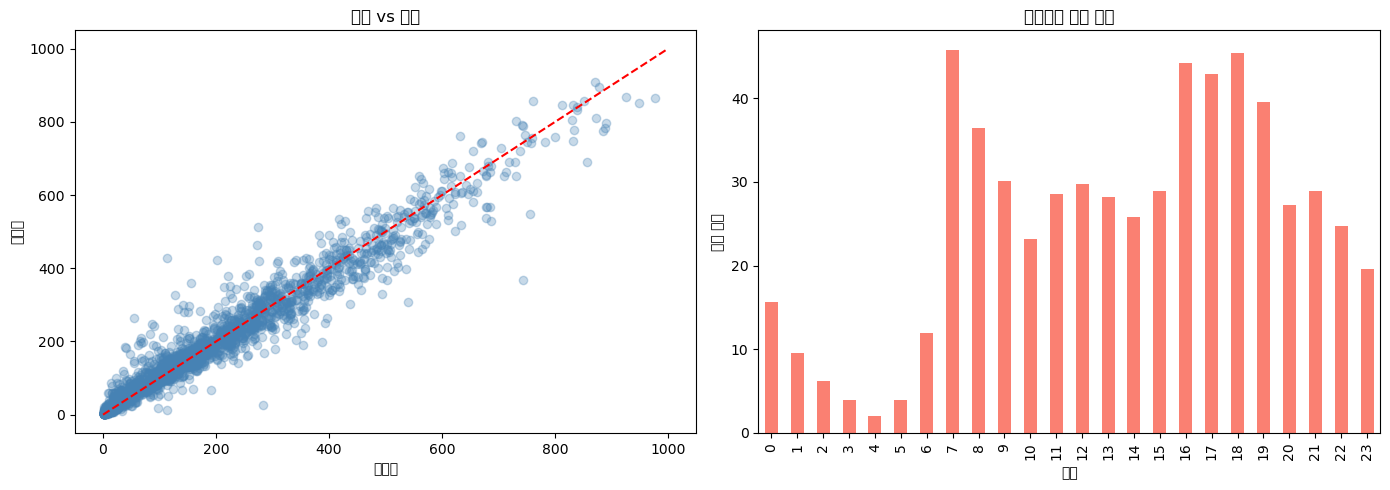

In [22]:
# 실제 vs 예측 비교
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, pred, alpha=0.3, color='steelblue')
plt.plot([0, 1000], [0, 1000], 'r--')  # 대각선
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.title('실제 vs 예측')

plt.subplot(1, 2, 2)
error_df = pd.DataFrame({
    'hour': X_test['hr'].values,
    'abs_error': np.abs(pred - y_test.values)
})
error_df.groupby('hour')['abs_error'].mean().plot(kind='bar', color='salmon')
plt.title('시간대별 평균 오차')
plt.xlabel('시간')
plt.ylabel('평균 오차')

plt.tight_layout()
plt.show()

## 최종 결론

### RMSE 개선 과정

- 1단계: 기본 RandomForest → RMSE 42.55
- 2단계: 피처 엔지니어링 추가 → RMSE 개선

### 인사이트

- 시간(hr)이 자전거 대여량에 가장 큰 영향
- 출퇴근 시간대(8시, 17~18시) 대여량 급증
- 맑은 날씨일수록 대여량 증가
- 피처 엔지니어링으로 모델 성능 개선